In [108]:
import requests

response = requests.get("https://api-web.nhle.com/v1/schedule/2025-10-07")
print(response.status_code)
print(response.json())

200
{'nextStartDate': '2025-10-14', 'previousStartDate': '2025-09-30', 'gameWeek': [{'date': '2025-10-07', 'dayAbbrev': 'TUE', 'numberOfGames': 3, 'datePromo': [], 'games': [{'id': 2025020001, 'season': 20252026, 'gameType': 2, 'venue': {'default': 'Amerant Bank Arena'}, 'neutralSite': False, 'startTimeUTC': '2025-10-07T21:00:00Z', 'easternUTCOffset': '-04:00', 'venueUTCOffset': '-04:00', 'venueTimezone': 'US/Eastern', 'gameState': 'OFF', 'gameScheduleState': 'OK', 'tvBroadcasts': [{'id': 309, 'market': 'N', 'countryCode': 'US', 'network': 'ESPN', 'sequenceNumber': 10}, {'id': 284, 'market': 'N', 'countryCode': 'CA', 'network': 'SN1', 'sequenceNumber': 113}, {'id': 281, 'market': 'N', 'countryCode': 'CA', 'network': 'TVAS', 'sequenceNumber': 120}], 'awayTeam': {'id': 16, 'commonName': {'default': 'Blackhawks'}, 'placeName': {'default': 'Chicago'}, 'placeNameWithPreposition': {'default': 'Chicago', 'fr': 'de Chicago'}, 'abbrev': 'CHI', 'logo': 'https://assets.nhle.com/logos/nhl/svg/CHI_

In [109]:
response.json()['gameWeek'][0].keys()

dict_keys(['date', 'dayAbbrev', 'numberOfGames', 'datePromo', 'games'])

In [110]:
data = response.json()
print('Season start:', data['regularSeasonStartDate'])
print('Season end:', data['regularSeasonEndDate'])

Season start: 2025-10-07
Season end: 2026-04-17


In [111]:
game = data['gameWeek'][0]['games'][0]
print(game.keys())

dict_keys(['id', 'season', 'gameType', 'venue', 'neutralSite', 'startTimeUTC', 'easternUTCOffset', 'venueUTCOffset', 'venueTimezone', 'gameState', 'gameScheduleState', 'tvBroadcasts', 'awayTeam', 'homeTeam', 'periodDescriptor', 'gameOutcome', 'winningGoalie', 'winningGoalScorer', 'threeMinRecap', 'threeMinRecapFr', 'gameCenterLink'])


In [112]:

import pandas as pd

df_games = pd.DataFrame(response.json()['gameWeek'][0]['games'])
df_games["away_team"] = df_games["awayTeam"].apply(lambda x: x['abbrev'])
df_games["home_team"] = df_games["homeTeam"].apply(lambda x: x['abbrev'])
df_games["away_score"] = df_games["awayTeam"].apply(lambda x: x['score'])
df_games["home_score"] = df_games["homeTeam"].apply(lambda x: x['score'])
df_games["outcome_type"] = df_games["gameOutcome"].apply(lambda x: x['lastPeriodType'])

df_games = df_games[df_games['gameType'] == 2]

df_games = df_games[['id','startTimeUTC','venueTimezone','away_team','home_team','away_score','home_score','outcome_type']]

df_games['winner'] = df_games.apply(lambda x: x['away_team'] if x['away_score'] > x['home_score'] else x['home_team'], axis=1)

df_games.head()

,id,startTimeUTC,venueTimezone,away_team,home_team,away_score,home_score,outcome_type,winner
0,2025020001,2025-10-07T21:00:00Z,US/Eastern,CHI,FLA,2,3,REG,FLA
1,2025020002,2025-10-08T00:00:00Z,America/New_York,PIT,NYR,3,0,REG,PIT
2,2025020003,2025-10-08T02:30:00Z,America/Los_Angeles,COL,LAK,4,1,REG,COL


In [113]:
from datetime import datetime

all_games = []
current_date = '2025-10-07'
season_end = '2026-04-17'

while current_date <= season_end:
    response = requests.get(f"https://api-web.nhle.com/v1/schedule/{current_date}")
    data = response.json()
    
    for day in data['gameWeek']:
        df_games = pd.DataFrame(day['games'])
        if df_games.empty:
            continue
        df_games["away_team"] = df_games["awayTeam"].apply(lambda x: x['abbrev'])
        df_games["home_team"] = df_games["homeTeam"].apply(lambda x: x['abbrev'])
        df_games["away_score"] = df_games["awayTeam"].apply(lambda x: x['score'])
        df_games["home_score"] = df_games["homeTeam"].apply(lambda x: x['score'])
        df_games["outcome_type"] = df_games["gameOutcome"].apply(lambda x: x['lastPeriodType'])

        df_games = df_games[df_games['gameType'] == 2]

        df_games = df_games[['id','startTimeUTC','venueTimezone','away_team','home_team','away_score','home_score','outcome_type']]

        df_games['winner'] = df_games.apply(lambda x: x['away_team'] if x['away_score'] > x['home_score'] else x['home_team'], axis=1)
        
        all_games.append(df_games)
    current_date = data['nextStartDate']

df_schedule = pd.concat(all_games, ignore_index=True)
print(df_schedule.shape)

(1312, 9)


In [114]:
df_schedule.head()

,id,startTimeUTC,venueTimezone,away_team,home_team,away_score,home_score,outcome_type,winner
0,2025020001,2025-10-07T21:00:00Z,US/Eastern,CHI,FLA,2,3,REG,FLA
1,2025020002,2025-10-08T00:00:00Z,America/New_York,PIT,NYR,3,0,REG,PIT
2,2025020003,2025-10-08T02:30:00Z,America/Los_Angeles,COL,LAK,4,1,REG,COL
3,2025020004,2025-10-08T23:00:00Z,America/Toronto,MTL,TOR,2,5,REG,TOR
4,2025020005,2025-10-08T23:30:00Z,US/Eastern,BOS,WSH,3,1,REG,BOS


In [115]:
import sqlite3
conn = sqlite3.connect('../database/nhl.db')

# Save to raw data
df_schedule.to_csv('../data/raw/schedule_2025_26.csv', index=False)

# Save to database
df_schedule.to_sql('schedule', conn, if_exists='replace', index=False)

print("Saved!")

Saved!


In [116]:
df_away = df_schedule[['id','away_team','startTimeUTC']]
df_away.rename(columns={'away_team': 'team'}, inplace=True)
df_away['location'] = 'away'

df_home = df_schedule[['id','home_team','startTimeUTC']]
df_home.rename(columns={'home_team': 'team'}, inplace=True)
df_home['location'] = 'home'

df_sched = pd.concat([df_away, df_home], ignore_index=True)
df_sched.head()


,id,team,startTimeUTC,location
0,2025020001,CHI,2025-10-07T21:00:00Z,away
1,2025020002,PIT,2025-10-08T00:00:00Z,away
2,2025020003,COL,2025-10-08T02:30:00Z,away
3,2025020004,MTL,2025-10-08T23:00:00Z,away
4,2025020005,BOS,2025-10-08T23:30:00Z,away


In [117]:
df_sched['date'] = pd.to_datetime(df_sched['startTimeUTC']).dt.date
df_sched.head()

,id,team,startTimeUTC,location,date
0,2025020001,CHI,2025-10-07T21:00:00Z,away,2025-10-07
1,2025020002,PIT,2025-10-08T00:00:00Z,away,2025-10-08
2,2025020003,COL,2025-10-08T02:30:00Z,away,2025-10-08
3,2025020004,MTL,2025-10-08T23:00:00Z,away,2025-10-08
4,2025020005,BOS,2025-10-08T23:30:00Z,away,2025-10-08


In [118]:
df_sched = df_sched.sort_values(['team', 'date']).reset_index(drop=True)
df_sched.head(10)

,id,team,startTimeUTC,location,date
0,2025020021,ANA,2025-10-10T02:00:00Z,away,2025-10-10
1,2025020036,ANA,2025-10-12T02:00:00Z,away,2025-10-12
2,2025020056,ANA,2025-10-15T02:30:00Z,home,2025-10-15
3,2025020070,ANA,2025-10-17T02:00:00Z,home,2025-10-17
4,2025020091,ANA,2025-10-19T23:00:00Z,away,2025-10-19
5,2025020105,ANA,2025-10-22T00:00:00Z,away,2025-10-22
6,2025020111,ANA,2025-10-23T23:00:00Z,away,2025-10-23
7,2025020129,ANA,2025-10-25T21:00:00Z,away,2025-10-25
8,2025020153,ANA,2025-10-28T23:00:00Z,away,2025-10-28
9,2025020180,ANA,2025-11-01T02:00:00Z,home,2025-11-01


In [119]:
df_sched['date'] = pd.to_datetime(df_sched['date'])
df_sched['rest_days'] = df_sched.groupby('team')['date'].diff().dt.days - 1

df_sched.head(10)

,id,team,startTimeUTC,location,date,rest_days
0,2025020021,ANA,2025-10-10T02:00:00Z,away,2025-10-10,NaN
1,2025020036,ANA,2025-10-12T02:00:00Z,away,2025-10-12,1.0
2,2025020056,ANA,2025-10-15T02:30:00Z,home,2025-10-15,2.0
3,2025020070,ANA,2025-10-17T02:00:00Z,home,2025-10-17,1.0
4,2025020091,ANA,2025-10-19T23:00:00Z,away,2025-10-19,1.0
5,2025020105,ANA,2025-10-22T00:00:00Z,away,2025-10-22,2.0
6,2025020111,ANA,2025-10-23T23:00:00Z,away,2025-10-23,0.0
7,2025020129,ANA,2025-10-25T21:00:00Z,away,2025-10-25,1.0
8,2025020153,ANA,2025-10-28T23:00:00Z,away,2025-10-28,2.0
9,2025020180,ANA,2025-11-01T02:00:00Z,home,2025-11-01,3.0


In [120]:
df_schedule['date'] = pd.to_datetime(df_schedule['startTimeUTC']).dt.date
df_schedule['date'] = pd.to_datetime(df_schedule['date'])

df_away_rest = df_schedule.merge(df_sched, left_on=['away_team', 'id'], right_on=['team', 'id'])
df_away_rest.rename(columns={'rest_days': 'away_rest'}, inplace=True)

df_home_rest = df_schedule.merge(df_sched, left_on=['home_team', 'id'], right_on=['team', 'id'])
df_home_rest.rename(columns={'rest_days': 'home_rest'}, inplace=True)

df_final = df_away_rest.merge(df_home_rest[['id','home_rest']],on='id',how='left')

print(df_final.shape)
df_final[['id','away_team','home_team','away_rest','home_rest']].head(50)

(1312, 16)


,id,away_team,home_team,away_rest,home_rest
0,2025020001,CHI,FLA,NaN,NaN
1,2025020002,PIT,NYR,NaN,NaN
2,2025020003,COL,LAK,NaN,NaN
3,2025020004,MTL,TOR,NaN,NaN
4,2025020005,BOS,WSH,NaN,NaN
5,2025020006,CGY,EDM,NaN,NaN
6,2025020007,LAK,VGK,0.0,NaN
7,2025020008,CHI,BOS,1.0,0.0
8,2025020009,NYR,BUF,0.0,NaN
9,2025020010,MTL,DET,0.0,NaN


In [121]:
#print(df_away_rest['id'].nunique())
#print(df_away_rest.shape)

df_away_rest[df_away_rest.duplicated(subset='id', keep=False)].head(10)

df_final[['id', 'away_team', 'home_team', 'away_rest', 'home_rest', 'winner']].iloc[50:60]

,id,away_team,home_team,away_rest,home_rest,winner
50,2025020051,EDM,NYR,1.0,1.0,EDM
51,2025020052,TBL,WSH,0.0,1.0,WSH
52,2025020053,VGK,CGY,2.0,3.0,VGK
53,2025020054,MIN,DAL,0.0,2.0,DAL
54,2025020055,CAR,SJS,3.0,2.0,CAR
55,2025020056,PIT,ANA,3.0,2.0,ANA
56,2025020057,OTT,BUF,1.0,1.0,BUF
57,2025020058,FLA,DET,1.0,1.0,DET
58,2025020059,CHI,STL,1.0,2.0,CHI
59,2025020060,CGY,UTA,0.0,1.0,UTA


In [122]:
df_final['rest_diff'] = df_final['away_rest'] - df_final['home_rest']

df_final.head(50)

,id,startTimeUTC_x,venueTimezone,away_team,home_team,away_score,home_score,outcome_type,winner,date_x,team,startTimeUTC_y,location,date_y,away_rest,home_rest,rest_diff
0,2025020001,2025-10-07T21:00:00Z,US/Eastern,CHI,FLA,2,3,REG,FLA,2025-10-07,CHI,2025-10-07T21:00:00Z,away,2025-10-07,NaN,NaN,NaN
1,2025020002,2025-10-08T00:00:00Z,America/New_York,PIT,NYR,3,0,REG,PIT,2025-10-08,PIT,2025-10-08T00:00:00Z,away,2025-10-08,NaN,NaN,NaN
2,2025020003,2025-10-08T02:30:00Z,America/Los_Angeles,COL,LAK,4,1,REG,COL,2025-10-08,COL,2025-10-08T02:30:00Z,away,2025-10-08,NaN,NaN,NaN
3,2025020004,2025-10-08T23:00:00Z,America/Toronto,MTL,TOR,2,5,REG,TOR,2025-10-08,MTL,2025-10-08T23:00:00Z,away,2025-10-08,NaN,NaN,NaN
4,2025020005,2025-10-08T23:30:00Z,US/Eastern,BOS,WSH,3,1,REG,BOS,2025-10-08,BOS,2025-10-08T23:30:00Z,away,2025-10-08,NaN,NaN,NaN
5,2025020006,2025-10-09T02:00:00Z,America/Edmonton,CGY,EDM,4,3,SO,CGY,2025-10-09,CGY,2025-10-09T02:00:00Z,away,2025-10-09,NaN,NaN,NaN
6,2025020007,2025-10-09T02:00:00Z,US/Pacific,LAK,VGK,6,5,SO,LAK,2025-10-09,LAK,2025-10-09T02:00:00Z,away,2025-10-09,0.0,NaN,NaN
7,2025020008,2025-10-09T23:00:00Z,US/Eastern,CHI,BOS,3,4,OT,BOS,2025-10-09,CHI,2025-10-09T23:00:00Z,away,2025-10-09,1.0,0.0,1.0
8,2025020009,2025-10-09T23:00:00Z,America/New_York,NYR,BUF,4,0,REG,NYR,2025-10-09,NYR,2025-10-09T23:00:00Z,away,2025-10-09,0.0,NaN,NaN
9,2025020010,2025-10-09T23:00:00Z,America/Detroit,MTL,DET,5,1,REG,MTL,2025-10-09,MTL,2025-10-09T23:00:00Z,away,2025-10-09,0.0,NaN,NaN


In [123]:
df_final.to_csv('../data/raw/schedule_with_rest_nhl_2025_26.csv', index=False)

# Save to database
df_final.to_sql('schedule', conn, if_exists='replace', index=False)

print("Saved!")

Saved!


In [124]:
df_away_b2b = df_final[df_final['away_rest'] == 0]

away_b2b_win_rate = (df_away_b2b['winner'] == df_away_b2b['away_team']).mean()

print(f"Away team win rate on back-to-backs: {away_b2b_win_rate:.1%}")
print(f"Sample size: {len(df_away_b2b)} games")

Away team win rate on back-to-backs: 42.0%
Sample size: 350 games


In [126]:
away_overall_win_rate = (df_final['winner'] == df_final['away_team']).mean()

print(f"Away team win rate overall: {away_overall_win_rate:.1%}")
print(f"Sample size: {len(df_final)} games")

Away team win rate overall: 47.8%
Sample size: 1312 games


**Context note:** The 2025-26 NHL season included an Olympic break, 
which compressed the schedule in surrounding weeks. This may inflate 
the frequency of back-to-back games compared to a typical season and 
should be considered when interpreting fatigue effects.

In [127]:
df_home_b2b = df_final[df_final['home_rest'] == 0]

home_b2b_win_rate = (df_home_b2b['winner'] == df_home_b2b['home_team']).mean()

print(f"Home team win rate on back-to-backs: {home_b2b_win_rate:.1%}")
print(f"Sample size: {len(df_home_b2b)} games")

Home team win rate on back-to-backs: 54.5%
Sample size: 253 games


In [128]:
home_overall_win_rate = (df_final['winner'] == df_final['home_team']).mean()

print(f"Home team win rate overall: {home_overall_win_rate:.1%}")
print(f"Sample size: {len(df_final)} games")

Home team win rate overall: 52.2%
Sample size: 1312 games


In [129]:
print("=== H1: Back-to-Back Win Rates ===")
print(f"Overall away win rate:        {away_overall_win_rate:.1%} (n={len(df_final)})")
print(f"Away win rate on B2B:         {away_b2b_win_rate:.1%} (n={len(df_away_b2b)})")
print(f"Home win rate on B2B:         {home_b2b_win_rate:.1%} (n={len(df_home_b2b)})")
print(f"Away B2B impact:              {away_b2b_win_rate - away_overall_win_rate:.1%}")

=== H1: Back-to-Back Win Rates ===
Overall away win rate:        47.8% (n=1312)
Away win rate on B2B:         42.0% (n=350)
Home win rate on B2B:         54.5% (n=253)
Away B2B impact:              -5.8%


**H3 Enrichment — Back-to-Back Types:**
Not all back-to-backs are equal. A home→away back-to-back involves 
playing then immediately traveling, compounding fatigue beyond rest 
days alone. We can categorize B2B games into four types using the 
`location` field in `df_sched`:

- **Home → Away** (hardest — play then travel overnight)
- **Away → Home** (travel then play in front of home crowd)  
- **Away → Away** (consecutive road games, continuous travel)
- **Home → Home** (easiest — no travel component)

The Penguins/Capitals example in March 2026 (PIT then WSH) is a 
classic Home → Away back-to-back. Incorporate into H3 timezone 
travel analysis.

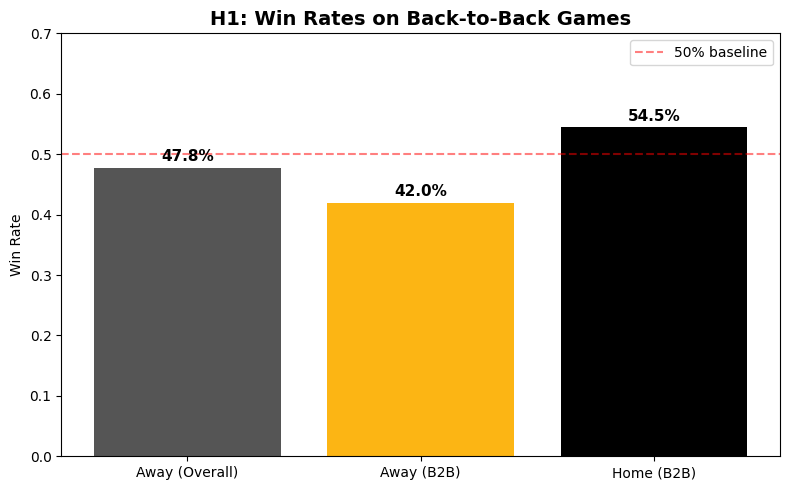

In [131]:
# =============================================================
# VISUALIZATION: H1 Back-to-Back Win Rates
# =============================================================

import matplotlib.pyplot as plt
import seaborn as sns

labels = ['Away (Overall)', 'Away (B2B)', 'Home (B2B)']
values = [away_overall_win_rate, away_b2b_win_rate, home_b2b_win_rate]
colors = ['#555555', '#FCB514', '#000000']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% baseline')
ax.set_ylabel('Win Rate')
ax.set_title('H1: Win Rates on Back-to-Back Games', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.7)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.savefig('../visuals/08_h1_b2b_win_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [135]:
# away team had more rest
df_away_rest = df_final[df_final['rest_diff'] > 0]

away_rest_win_rate = (df_away_rest['winner'] == df_away_rest['away_team']).mean()

print(f"Away team win rate when more rested: {away_rest_win_rate:.1%}")
print(f"Sample size: {len(df_away_rest)} games")

# teams had equal rest
away_equal_rest = df_final[df_final['rest_diff'] == 0]

away_equal_win_rate = (away_equal_rest['winner'] == away_equal_rest['away_team']).mean()

print(f"Away team win rate on equal rest: {away_equal_win_rate:.1%}")
print(f"Sample size: {len(away_equal_rest)} games")

# away team had more rest
df_home_rest = df_final[df_final['rest_diff'] < 0]

away_tired_win_rate = (df_home_rest['winner'] == df_home_rest['away_team']).mean()

print(f"Away team win rate on less rest: {away_tired_win_rate:.1%}")
print(f"Sample size: {len(df_home_rest)} games")

Away team win rate when more rested: 51.1%
Sample size: 274 games
Away team win rate on equal rest: 50.2%
Sample size: 624 games
Away team win rate on less rest: 41.4%
Sample size: 394 games


In [133]:
df_final['rest_diff'].value_counts().sort_index()

rest_diff
-21.0      1
-20.0      4
-5.0       2
-4.0       5
-3.0      21
-2.0      65
-1.0     296
 0.0     624
 1.0     211
 2.0      50
 3.0       6
 4.0       5
 5.0       1
 21.0      1
Name: count, dtype: int64